<a href="https://colab.research.google.com/github/muhyassin09/yasinnn/blob/main/menuju-indonesia-emas-2045/notebooks/02_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Name: Indonesian Municipal Fiscal Analytics Framework
## Module: 02_Data_Analysis

**Project Pipeline Status:**
- [x] **00_Data_Acquisition.ipynb** -> Documents the source publication and how the raw table data was extracted from BPS PDF reports.
- [x] **01_Data_Preprocessing.ipynb** -> Loads the raw BPS fiscal CSV and runs data-quality checks (shape, dtypes, missing values, duplicates).
- [ ] **02_Data_Analysis.ipynb** *(current)* -> Explores distribution shape/skewness of the 8 fiscal ratios and applies a log1p transform where it helps.
- [ ] **03_Modelling.ipynb** -> Standardizes features, selects k, fits K-Means (k=4), and profiles/visualizes the resulting clusters.
- [ ] **04_Finalizing.ipynb** -> Checks the geographic pattern of clusters, saves the final labeled dataset, and writes the project summary.

---
### 🎯 Module Objective
Examine the shape of each fiscal ratio's distribution, quantify skewness, and correct it with a log1p transform where it genuinely helps — checked per column rather than applied blindly.

### 📥 Data Ingestion
* **Source File:** `data/processed/checked_fiscal_indicators_indonesia_2023.csv`
* **Current Shape:** 508 rows × 10 columns

---


### 🛠️ Environment Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
!git clone https://github.com/muhyassin09/yasinnn

fatal: destination path 'yasinnn' already exists and is not an empty directory.


In [7]:
df = pd.read_csv('/content/yasinnn/menuju-indonesia-emas-2045/data/processed/checked_fiscal_indicators_indonesia_2023.csv')
print('Loaded shape:', df.shape)


Loaded shape: (508, 10)


## 4. Exploring distributions

Fiscal ratios like these are rarely bell-shaped. A handful of regions (major cities, resource-rich regencies) tend to sit far above the rest, which makes distributions **right-skewed** with **long tails**. This matters a lot for later modeling — most models assume features are roughly on comparable, well-behaved scales to avoid distorted results.

Let's measure skewness for each ratio and look at the shape visually.

In [9]:
ratio_cols = [
    'derajat_desentralisasi_2023',
    'rasio_kemandirian_2023',
    'tingkat_penyerapan_pendapatan',
    'tingkat_penyerapan_belanja',
    'rasio_pajak',
    'rasio_efektivitas_pad',
    'rasio_efektivitas_pajak',
    'rasio_belanja_thd_pendapatan',
]

skewness = df[ratio_cols].skew().sort_values(ascending=False)
print("Skewness per indicator (0 = symmetric, higher = more right-skewed):")
print(skewness.round(2))

Skewness per indicator (0 = symmetric, higher = more right-skewed):
rasio_kemandirian_2023           14.09
rasio_efektivitas_pad             7.68
rasio_pajak                       3.43
rasio_efektivitas_pajak           2.86
derajat_desentralisasi_2023       2.11
tingkat_penyerapan_pendapatan     2.10
tingkat_penyerapan_belanja        1.68
rasio_belanja_thd_pendapatan      0.40
dtype: float64


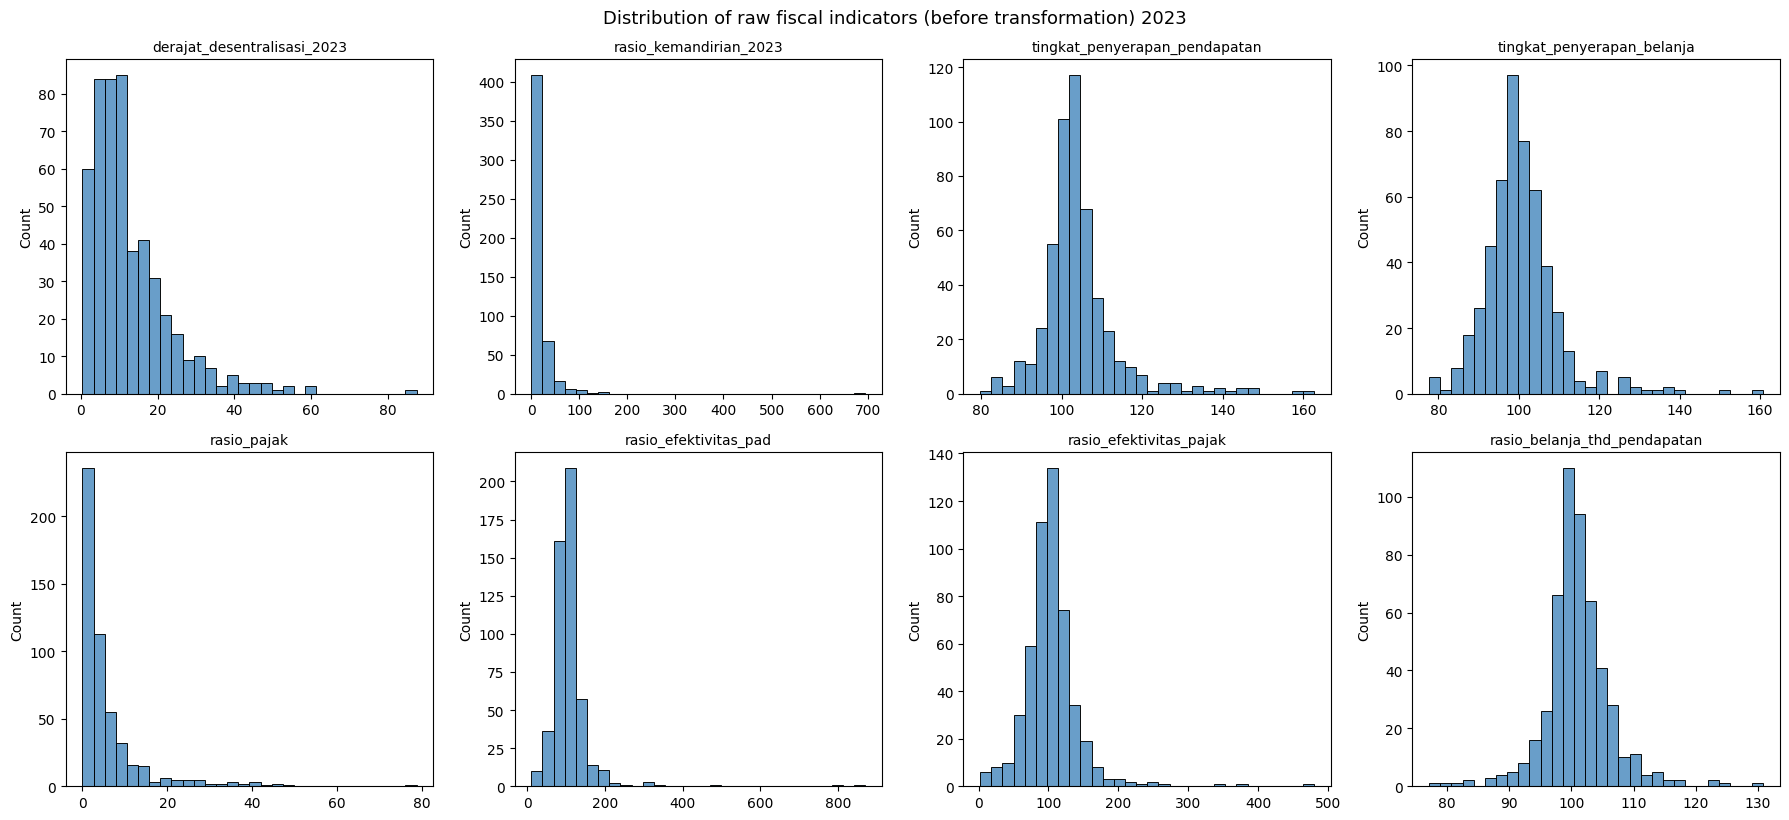

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(ratio_cols):
    sns.histplot(df[col], bins=30, ax=axes[i], color='#377eb8')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.suptitle('Distribution of raw fiscal indicators (before transformation) 2023', y=1.02, fontsize=13)
plt.savefig('fig1_raw_distributions.png')
plt.show()

**Observation:** several indicators are heavily right-skewed (`rasio_kemandirian_2023` and `rasio_efektivitas_pad` especially), driven by a small number of genuinely high-capacity regions — for example, Kab. Badung in Bali (tourism tax base) and a few resource-rich regencies in Kalimantan and Papua with very high revenue-effectiveness ratios. These are **real values, not data errors** (we verified this by cross-checking a handful against the original BPS tables), so we don't want to remove them — but we do want to reduce their disproportionate pull on models that assume roughly normal-shaped data.

## 5. Handling skewness with log transformation

A standard fix for right-skewed, strictly-positive ratio data is a **log transform**. We use `log1p` (i.e. `log(1 + x)`) rather than a plain `log`, because some values are exactly 0 (e.g. `rasio_pajak` has a minimum of 0.00), and `log(0)` is undefined.

This compresses large values much more than small ones, pulling in the long right tail without discarding any data points.

In [12]:
for col in ratio_cols:
    df[f'log_{col}'] = np.log1p(df[col])

log_cols = [f'log_{col}' for col in ratio_cols]

skew_comparison = pd.DataFrame({
    'skew_before': df[ratio_cols].skew().values,
    'skew_after_log': df[log_cols].skew().values,
}, index=ratio_cols)

print(skew_comparison.round(2))

                               skew_before  skew_after_log
derajat_desentralisasi_2023           2.11           -0.17
rasio_kemandirian_2023               14.09            0.29
tingkat_penyerapan_pendapatan         2.10            1.41
tingkat_penyerapan_belanja            1.68            0.99
rasio_pajak                           3.43            0.74
rasio_efektivitas_pad                 7.68            0.06
rasio_efektivitas_pajak               2.86           -2.28
rasio_belanja_thd_pendapatan          0.40           -0.14


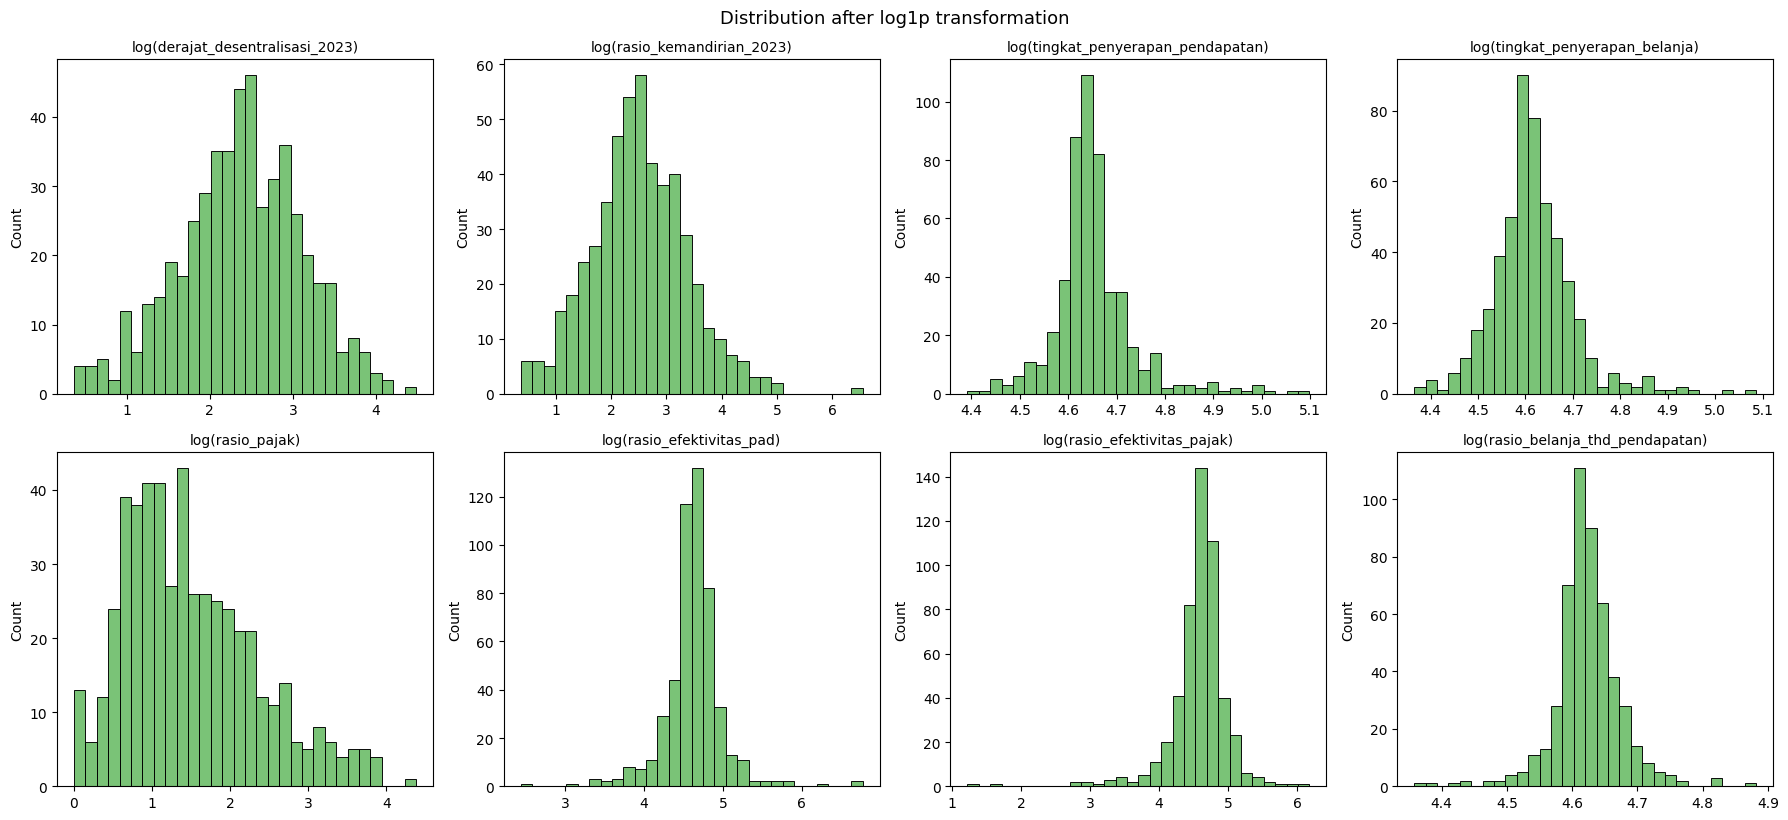

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(ratio_cols):
    sns.histplot(df[f'log_{col}'], bins=30, ax=axes[i], color='#4daf4a')
    axes[i].set_title(f'log({col})', fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.suptitle('Distribution after log1p transformation', y=1.02, fontsize=13)
plt.savefig('fig2_log_distributions.png')
plt.show()

**Result:** most indicators improve a lot — `rasio_kemandirian_2023` drops from a skew of 14.09 to 0.29, and `rasio_efektivitas_pad` from 7.68 to 0.06. Two are worth flagging honestly rather than glossing over:

- `tingkat_penyerapan_pendapatan` only partially improves (2.10 → 1.41) — still moderately skewed.
- `rasio_efektivitas_pajak` actually gets *more* skewed in the other direction (2.86 → -2.28). This happens because it's a ratio centered around 100 rather than near 0, so `log1p` compresses its upper tail more than its lower spread warrants — a reminder that log transform is a reasonable default, not a universal fix, and should be checked per column rather than applied blindly.

We keep the log-transformed columns as a working default for the clustering notebook, but this is a good candidate to revisit later (e.g. a per-column transform, or simply accepting moderate residual skew since K-Means with standardized inputs is fairly tolerant of it).

In [16]:
df.to_csv("processed_fiscal_indicators_indonesia_2023.csv", index=False)
print("Shape so far:", df.shape)



Shape so far: (508, 18)


<Figure size 640x480 with 0 Axes>

---
### 📤 Data Export & Handoff

* **Output File:**
`processed_fiscal_indicators_indonesia_2023.csv`
`fig1_raw_distributions.png`, `fig2_log_distributions.png`

* **Next Destination:** `notebooks/03_Modelling.ipynb`
